## 1. Exploration — distributions référence vs prod

=== Shapes & periode ===
reference_set   : (1500, 15)
prod_3months    : (3000, 16) | periode 2026-03-02 00:00:00 -> 2026-05-24 23:00:00
predictions_log : (3000, 5) | periode 2026-03-02 00:00:00 -> 2026-05-24 23:00:00

=== Valeurs manquantes (%) ===
                     reference  prod
loan_amnt                  0.0   0.0
term                       0.0   0.0
int_rate                   0.0   0.0
installment                0.0   0.0
grade                      0.0   0.0
emp_length                 3.3   3.8
home_ownership             0.0   0.0
annual_inc                 0.0   0.0
verification_status        0.0   0.0
purpose                    0.0   0.0
dti                        0.0   0.0
delinq_2yrs                0.0   0.0
fico_range_low             0.0   0.0
revol_util                 1.3   1.2
loan_status                0.0   0.0
timestamp                  NaN   0.0

=== Cible loan_status (%) ===
             reference  prod
loan_status                 
Fully Paid        82.5  80.9
Char

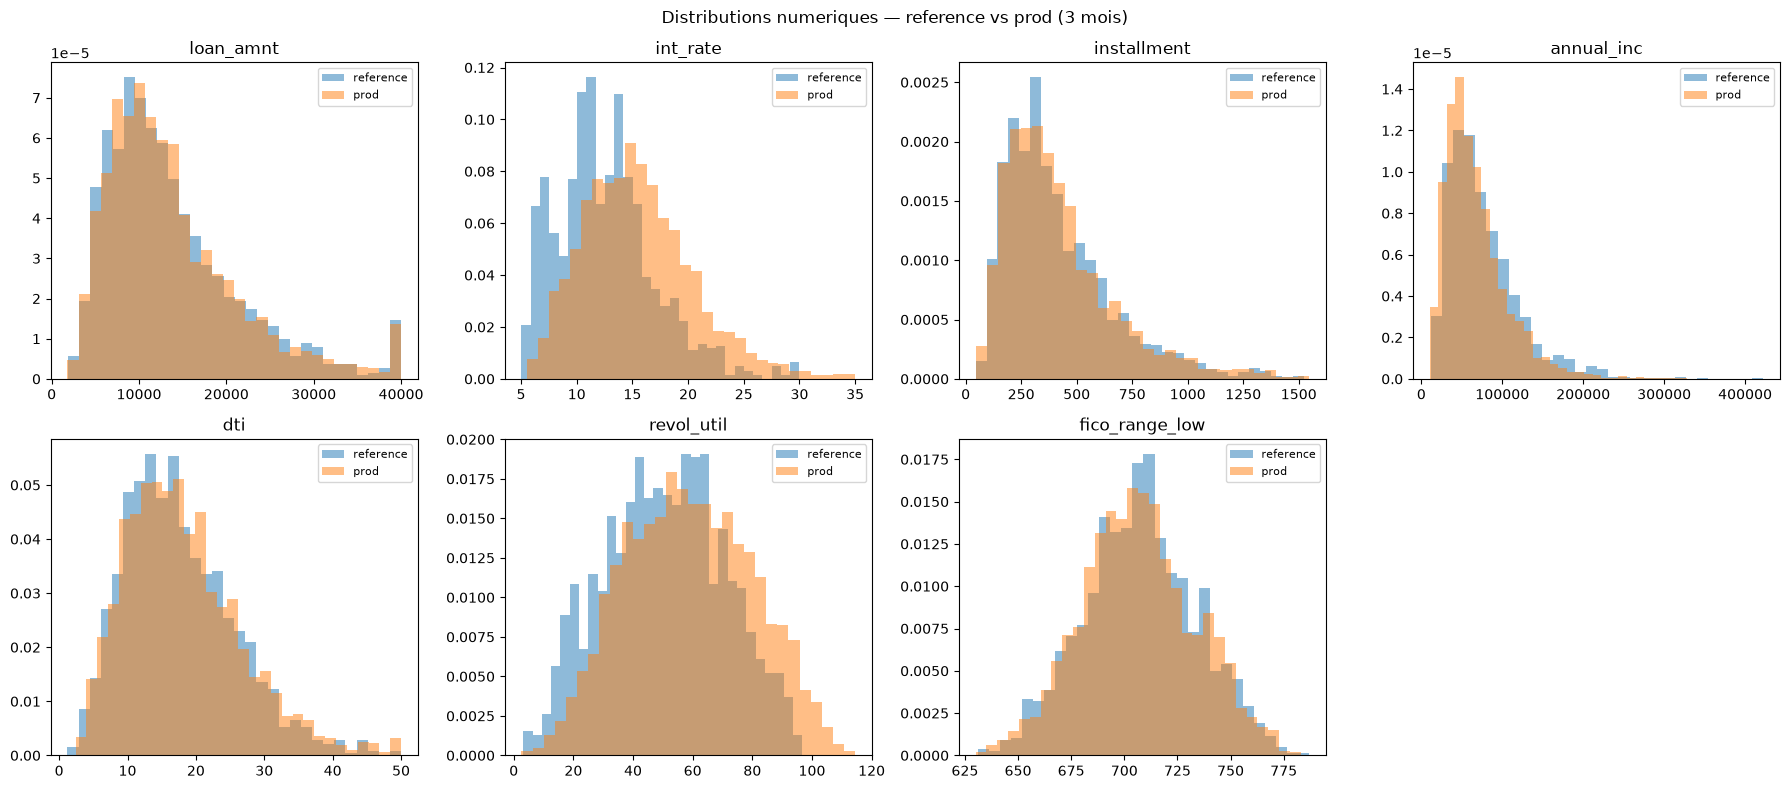

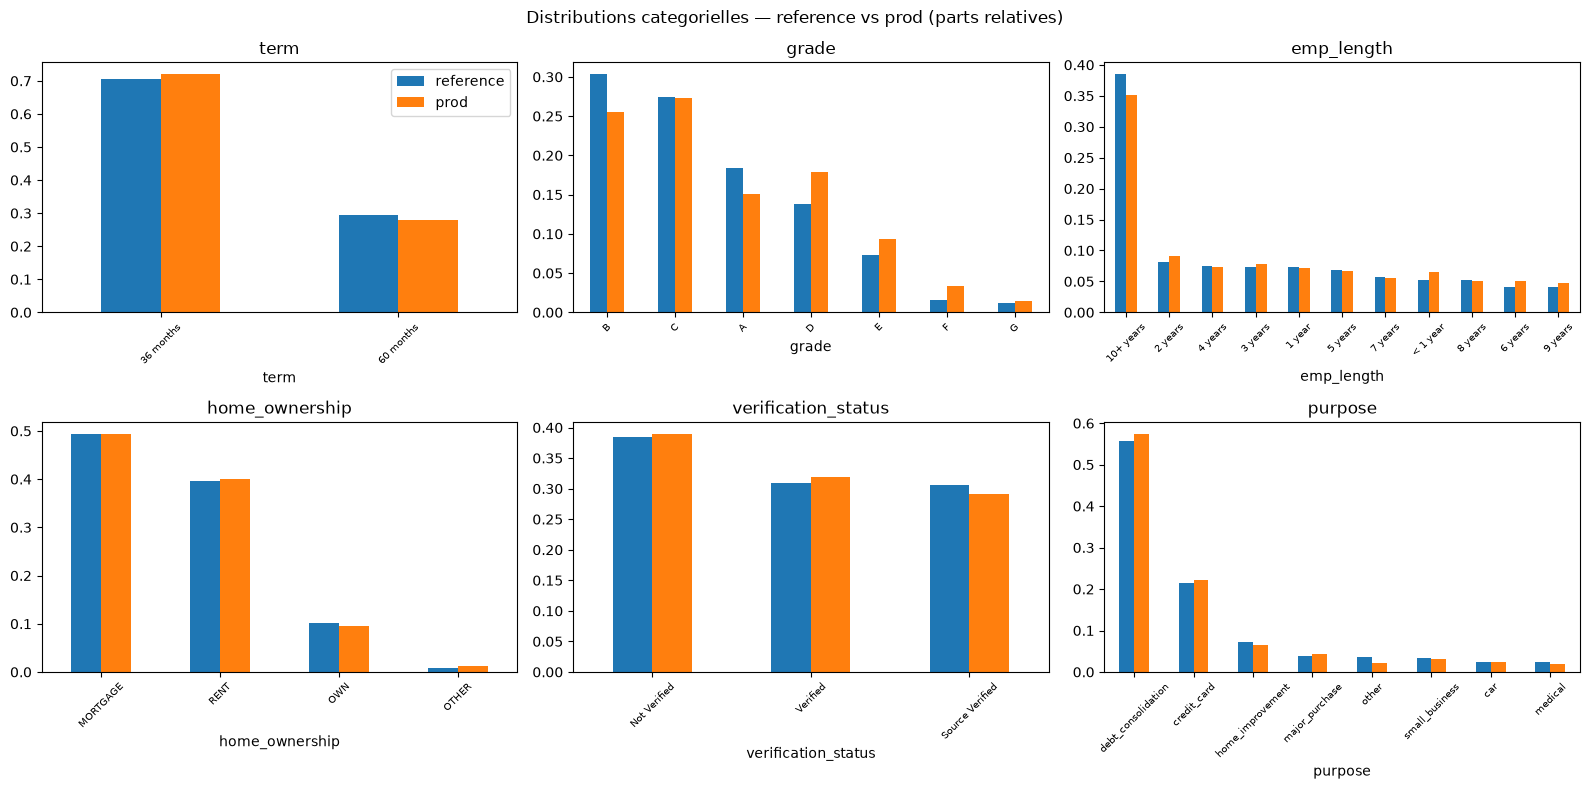

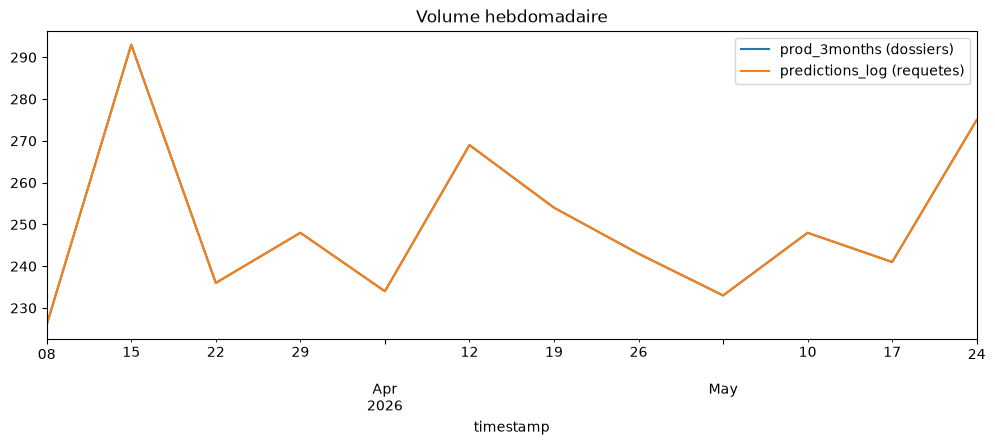

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("..") / "data"

reference = pd.read_csv(DATA_DIR / "reference_set.csv")
prod = pd.read_csv(DATA_DIR / "prod_3months.csv", parse_dates=["timestamp"])
predictions = pd.read_csv(DATA_DIR / "predictions_log.csv", parse_dates=["timestamp"])

NUMERIC_COLS = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "revol_util", "fico_range_low"]
CATEGORICAL_COLS = ["term", "grade", "emp_length", "home_ownership", "verification_status", "purpose"]

print("=== Shapes & periode ===")
print(f"reference_set   : {reference.shape}")
print(f"prod_3months    : {prod.shape} | periode {prod['timestamp'].min()} -> {prod['timestamp'].max()}")
print(f"predictions_log : {predictions.shape} | periode {predictions['timestamp'].min()} -> {predictions['timestamp'].max()}")

print("\n=== Valeurs manquantes (%) ===")
missing = pd.concat(
    {"reference": reference.isna().mean() * 100, "prod": prod.isna().mean() * 100},
    axis=1,
).round(1)
print(missing)

print("\n=== Cible loan_status (%) ===")
target_compare = pd.concat(
    {
        "reference": reference["loan_status"].value_counts(normalize=True) * 100,
        "prod": prod["loan_status"].value_counts(normalize=True) * 100,
    },
    axis=1,
).round(1)
print(target_compare)

print("\n=== predictions_log — taux modele / reel ===")
print(f"taux de prediction=1 (defaut predit) : {predictions['prediction'].mean() * 100:.1f} %")
print(f"taux de true_label=1 (defaut reel)   : {predictions['true_label'].mean() * 100:.1f} %")
print(f"proba_default moyenne                : {predictions['proba_default'].mean():.4f}")

print("\n=== Statistiques descriptives — features numeriques (reference vs prod) ===")
desc = pd.concat(
    {"reference": reference[NUMERIC_COLS].describe(), "prod": prod[NUMERIC_COLS].describe()},
    axis=1,
)
print(desc)

# Distributions numeriques superposees
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), NUMERIC_COLS):
    ax.hist(reference[col].dropna(), bins=30, alpha=0.5, density=True, label="reference")
    ax.hist(prod[col].dropna(), bins=30, alpha=0.5, density=True, label="prod")
    ax.set_title(col)
    ax.legend(fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("Distributions numeriques — reference vs prod (3 mois)")
fig.tight_layout()
plt.show()

# Distributions categorielles (parts relatives)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), CATEGORICAL_COLS):
    ref_pct = reference[col].value_counts(normalize=True)
    prod_pct = prod[col].value_counts(normalize=True)
    compare = pd.concat({"reference": ref_pct, "prod": prod_pct}, axis=1).fillna(0)
    compare.plot(kind="bar", ax=ax, legend=(col == CATEGORICAL_COLS[0]))
    ax.set_title(col)
    ax.tick_params(axis="x", labelsize=7, rotation=45)
fig.suptitle("Distributions categorielles — reference vs prod (parts relatives)")
fig.tight_layout()
plt.show()

# Volume dans le temps
prod_weekly = prod.set_index("timestamp").resample("W").size()
pred_weekly = predictions.set_index("timestamp").resample("W").size()
fig, ax = plt.subplots(figsize=(12, 4))
prod_weekly.plot(ax=ax, label="prod_3months (dossiers)")
pred_weekly.plot(ax=ax, label="predictions_log (requetes)")
ax.set_title("Volume hebdomadaire")
ax.legend()
plt.show()


### Conclusion — exploration

**Volumes et période.** `prod_3months.csv` (3000 dossiers) et `predictions_log.csv`
(3000 requêtes) couvrent la même période, du 2026-03-02 au 2026-05-24, avec un
volume hebdomadaire stable (~230 à 290 dossiers/semaine, pas de rupture visible).
`reference_set.csv` compte 1500 lignes ; les taux de valeurs manquantes
(`emp_length` ~3.3–3.8 %, `revol_util` ~1.2–1.3 %) sont quasi identiques entre
référence et prod : pas de problème de qualité de données côté prod.

**Cible réelle (`loan_status`).** Quasi stable : 17.5 % de défauts en référence
contre 19.1 % en prod. Cet écart est faible et ne suffit pas à lui seul à
expliquer une dérive.

**Indice fort de dérive côté features.** Plusieurs variables numériques se
décalent nettement entre référence et prod :
- `int_rate` : moyenne 12.6 → 15.5 (histogramme visiblement translaté vers la droite) ;
- `revol_util` : moyenne 50.6 → 59.0 ;
- `dti` : 17.6 → 18.2 (léger) ;
- `annual_inc` : 76 938 → 67 156 (revenus déclarés en baisse).

Côté catégoriel, le mix de `grade` se dégrade cohéremment avec la hausse de
`int_rate` : la part de grade B recule (30.5 % → 25.5 %) au profit des grades
D et E (13.9 %→17.6 % et 7.5 %→9.5 %). Les autres variables catégorielles
(`term`, `home_ownership`, `verification_status`, `purpose`, `emp_length`)
restent quasi inchangées. **Ce décalage concerté (int_rate, revol_util, grade)
est le signal de data drift à confirmer statistiquement en partie 2 (PSI/KS/Chi²).**

**Signal fort côté prédictions.** Sur `predictions_log.csv`, le modèle prédit
la classe défaut (`prediction=1`) dans 47.9 % des cas, avec une `proba_default`
moyenne de 0.476 (proche de 0.5, donc quasi indécise), alors que le taux réel
de défaut (`true_label`) n'est que de 19.1 %. Cet écart massif entre le taux
prédit et le taux réel est un signal fort de **miscalibration en production**,
à creuser en partie 3 (calibration) — et interroge aussi la performance du
modèle en partie 4 (le taux de faux positifs semble très élevé).

Trois interprétations possibles à ce stade (à trancher dans les parties suivantes) :

1. **Pas un simple problème de seuil.** Remonter le seuil de décision (>0.5)
   ne suffirait pas à corriger le tir : `proba_default` moyenne à 0.476 pour
   un taux réel de 19 % montre une **miscalibration systématique** sur
   l'ensemble du portefeuille (le modèle « gonfle » ses probabilités de
   défaut), pas seulement un mauvais réglage de coupure sur quelques cas limites.
2. **Conséquence possible du data drift.** Le modèle a été calé sur la
   distribution de référence ; si la prod dérive vers des profils plus
   risqués (`int_rate`, `revol_util`, `grade` en hausse), ses scores peuvent
   se décaler sans que ses probabilités restent fiables — il extrapole hors
   de sa zone de calage.
3. **Possible concept drift.** La relation features → probabilité de défaut
   a pu changer en prod : le modèle « voit » du risque dans les features qui
   ne se matérialise pas autant que prévu en réalité.

Le reliability diagram / ECE (partie 3) et l'évolution de l'AUC dans le temps
(partie 4) permettront de trancher entre ces hypothèses.


## 2. Détection statistique — PSI · KS · Chi²

In [3]:
import sys

sys.path.insert(0, str(Path("..") / "src"))
from drift_detection import PSI_DRIFT, PSI_STABLE, drift_report  # noqa: E402

report = drift_report(reference, prod, NUMERIC_COLS, CATEGORICAL_COLS)


def format_calcul(row: pd.Series) -> str:
    if row["type"] == "numerique":
        return f"PSI={row['psi']:.3f} ; KS p={row['ks_pvalue']:.3g}"
    return f"Chi2 p={row['chi2_pvalue']:.3g}"


def format_interpretation(row: pd.Series) -> str:
    if row["type"] == "numerique":
        if row["psi"] < PSI_STABLE:
            ampleur = "signal faible (PSI < 0.10)"
        elif row["psi"] < PSI_DRIFT:
            ampleur = "à investiguer (PSI 0.10-0.25)"
        else:
            ampleur = "signal fort (PSI > 0.25)"
        detectable = "KS significatif (p<0.05)" if row["ks_pvalue"] < 0.05 else "KS non significatif"
        return f"{ampleur} ; {detectable}"
    if row["chi2_pvalue"] < 0.05:
        return "Chi² significatif (p<0.05) : répartition des modalités différente"
    return "Chi² non significatif : répartition des modalités stable"


report["calcul"] = report.apply(format_calcul, axis=1)
report["interpretation"] = report.apply(format_interpretation, axis=1)

print("=== Tableau de synthèse — PSI · KS · Chi² (trié par sévérité) ===")
print(report[["feature", "type", "calcul", "verdict", "interpretation"]].to_string(index=False))

# Ecriture de drift_summary.md : colonnes "calcul" et "interpretation" distinctes
md_lines = [
    "# Synthèse drift — PSI · KS · Chi²",
    "",
    "Repères conventionnels PSI : < 0.10 signal faible, 0.10–0.25 signal à investiguer, > 0.25 signal fort.",
    "Ce sont des heuristiques de place, pas des lois statistiques : un chiffre n'est pas un verdict.",
    "",
    "| Feature | Type | Calcul | Verdict | Interprétation |",
    "|---|---|---|---|---|",
]
for _, row in report.iterrows():
    md_lines.append(
        f"| `{row['feature']}` | {row['type']} | {row['calcul']} | {row['verdict']} | {row['interpretation']} |"
    )

drift_summary_path = Path("..") / "drift_summary.md"
drift_summary_path.write_text("\n".join(md_lines) + "\n", encoding="utf-8")
print(f"\nEcrit : {drift_summary_path.resolve()}")


=== Tableau de synthèse — PSI · KS · Chi² (trié par sévérité) ===
            feature         type                    calcul verdict                                                    interpretation
           int_rate    numerique PSI=0.444 ; KS p=4.63e-65  dérive               signal fort (PSI > 0.25) ; KS significatif (p<0.05)
              grade categorielle           Chi2 p=3.65e-07  dérive Chi² significatif (p<0.05) : répartition des modalités différente
         revol_util    numerique PSI=0.187 ; KS p=3.82e-20 suspect          à investiguer (PSI 0.10-0.25) ; KS significatif (p<0.05)
         annual_inc    numerique PSI=0.067 ; KS p=2.28e-09  stable             signal faible (PSI < 0.10) ; KS significatif (p<0.05)
        installment    numerique    PSI=0.015 ; KS p=0.663  stable                  signal faible (PSI < 0.10) ; KS non significatif
                dti    numerique     PSI=0.011 ; KS p=0.11  stable                  signal faible (PSI < 0.10) ; KS non significatif
   

### Conclusion — détection statistique (PSI · KS · Chi²)

#### Pour rappel, à quoi servent ces 3 indicateurs ?

- **PSI (Population Stability Index)** — répond à *« l'écart est-il gros ou
  petit ? »*. On découpe la référence en 10 tranches et on regarde comment la
  prod se répartit dans ces mêmes tranches. C'est un **chiffre continu**, pas
  un test statistique : repères conventionnels **< 0.10 = signal faible,
  0.10–0.25 = à investiguer, > 0.25 = signal fort**. Ne s'applique qu'aux
  variables **numériques**.
- **KS (Kolmogorov-Smirnov)** — répond à *« cet écart pourrait-il être dû au
  hasard d'échantillonnage ? »*. Résultat : une **p-value** (< 0.05 = écart
  jugé réel, pas du bruit). ⚠️ Très sensible dès qu'on a beaucoup de lignes :
  il peut signaler comme « significatif » un écart en réalité minuscule.
  S'applique aux variables **numériques**.
- **Chi²** — l'équivalent du KS mais pour les variables **catégorielles**
  (`grade`, `term`, ...) : il compare, catégorie par catégorie, le nombre de
  dossiers observés en prod au nombre attendu si la répartition de la
  référence n'avait pas changé. Résultat aussi une **p-value** (< 0.05 =
  répartition des catégories différente).

**Règle d'or : on ne conclut jamais avec un seul chiffre.** PSI donne
l'ampleur, KS/Chi² confirment que ce n'est pas juste du bruit statistique.
Le tableau de synthèse (écrit dans `drift_summary.md`, colonnes **calcul** et
**interprétation** distinctes) croise ces indicateurs pour chaque feature :

- **`int_rate` (taux d'intérêt) : dérive forte.** PSI = 0.444 (bien au-dessus
  du seuil de 0.25) et KS p ≈ 5·10⁻⁶⁵ (quasi nul) : les deux méthodes sont
  d'accord, c'est la feature qui a le plus bougé entre référence et prod.
- **`grade` (catégorie de risque) : dérive.** Chi² p ≈ 3.7·10⁻⁷ : la
  répartition des grades a réellement changé (moins de bons profils B, plus
  de profils risqués D/E), ce n'est pas un hasard d'échantillonnage.
- **`revol_util` (taux d'utilisation du crédit renouvelable) : à
  investiguer.** PSI = 0.187, dans la zone intermédiaire 0.10–0.25, et KS
  significatif : un écart réel, mais moins marqué que celui d'`int_rate`.
- **`annual_inc` (revenu annuel) : signal faible malgré un KS très
  significatif** (p ≈ 2.3·10⁻⁹). C'est l'exemple parfait du piège à éviter :
  avec 1500 vs 3000 lignes, le KS détecte presque n'importe quel petit écart.
  Ici le PSI reste sous 0.10 (0.067) : l'écart est réel mais **trop petit pour
  être qualifié de dérive** — on se fie à l'ampleur (PSI), pas à la seule
  p-value.
- **Toutes les autres features (`installment`, `dti`, `fico_range_low`,
  `loan_amnt`, `term`, `emp_length`, `home_ownership`,
  `verification_status`, `purpose`) sont stables** : ni PSI, ni KS/Chi²
  significatifs.

**Synthèse globale, en une phrase.** La dérive n'est pas généralisée à tout
le jeu de données : elle est **concentrée sur 2 à 3 variables liées au risque
de crédit** (`int_rate`, `grade`, et dans une moindre mesure `revol_util`),
ce qui ressemble à un changement de mix de population (des profils plus
risqués arrivent en prod) plutôt qu'à un problème de qualité de données. Ce
diagnostic — **data drift localisé vs concept drift** — sera affiné en
partie 3 (calibration) et partie 4 (évolution de l'AUC dans le temps).


## 3. Calibration en exploitation

In [ ]:
# TODO


## 4. Performance dans le temps

In [ ]:
# TODO


## 5. Diagnostic & recommandation

In [ ]:
# TODO
